# 🚁 NOTEBOOK 06: INFERENCE VỚI LOGIC "STABILITY BUFFER"
**Project:** Intelligent Drone Flight Maneuver Recognition  
**Logic:** Stability Buffer (Chờ ổn định) - Thay thế cho Hard-coded Timer.

## 🎯 Mục tiêu
1. **Load Model:** Random Forest đã train.
2. **State Machine (New):**
   - Khi phát hiện va chạm (`LANDING`), chuyển sang trạng thái **LANDING_PROCESS**.
   - Giữ trạng thái này mãi mãi cho đến khi cảm biến báo **"Đã nằm im"** (Low Energy) trong 3 frame liên tiếp.
   - Ưu điểm: Tự động thích nghi với độ nảy của Drone khi tiếp đất.

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import linregress, kurtosis, skew
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

drive.mount('/content/drive')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)

# --- CONFIG ---
BASE_DIR = Path('/content/drive/MyDrive/Drone_Project_2025')
MODELS_DIR = BASE_DIR / 'models'
DATA_DIR = BASE_DIR / 'data/interim'

# Load Model
rf_model = joblib.load(MODELS_DIR / 'rf_model.joblib')
print("✅ Đã load Model Random Forest!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã load Model Random Forest!


## 🧠 1. ĐỊNH NGHĨA BỘ NÃO LOGIC (STABILITY BUFFER)
Logic: "Tao thấy mày va chạm rồi. Giờ tao sẽ chờ cho đến khi mày hết rung lắc thì mới thôi gọi là Landing."

In [ ]:
# ==============================================================================
# 🧠 LOGIC V4: STABILITY BUFFER + SMART TRIGGER (PHASE LOCK)
# ==============================================================================
class DroneFlightLogic:
    def __init__(self, stability_threshold=1.5, min_stable_frames=3):
        """
        stability_threshold: Ngưỡng rung (đã tăng lên 2.0 để dễ chịu hơn với tay run).
        min_stable_frames: Số frame cần nằm im để kết thúc hạ cánh.
        """
        # 1. Config cho Landing (Giữ nguyên)
        self.is_landing_process = False
        self.stable_counter = 0
        self.threshold = stability_threshold
        self.required_frames = min_stable_frames

        # 2. Config cho Flight Phase (MỚI: Smart Trigger)
        self.flight_mode_active = False # Cờ đánh dấu: Đã chính thức vào pha bay chưa?

    def process(self, raw_pred, current_features):
        """
        Input: raw_pred (AI), current_features (để check rung)
        """
        # --- A. LOGIC HẠ CÁNH (ƯU TIÊN CAO NHẤT) ---
        # Tính độ rung hiện tại
        current_instability = max(
            current_features.get('acc_x_std', 0),
            current_features.get('acc_y_std', 0),
            current_features.get('acc_z_std', 0)
        )

        if self.is_landing_process:
            # Kiểm tra độ ổn định
            if current_instability < self.threshold:
                self.stable_counter += 1
            else:
                self.stable_counter = 0 # Còn rung thì reset đếm

            # Nếu đã nằm im đủ lâu -> Hoàn tất hạ cánh
            if self.stable_counter >= self.required_frames:
                self.is_landing_process = False
                self.flight_mode_active = False # 🔥 RESET: Quay về trạng thái chờ (Giai đoạn đầu)
                self.stable_counter = 0
                return raw_pred # Trả quyền lại cho AI
            else:
                return 'LANDING' # Vẫn đang xử lý hạ cánh thì ép nhãn Landing

        # --- B. LOGIC KÍCH HOẠT CHẾ ĐỘ BAY (SMART TRIGGER) ---
        # Nếu chưa vào chế độ bay, kiểm tra xem có nên kích hoạt không?
        if not self.flight_mode_active:
            # Nếu gặp nhãn khác IDLE và TAKEOFF (VD: HOVER, MANEUVER...) -> KÍCH HOẠT NGAY
            if raw_pred not in ['IDLE', 'TAKEOFF']:
                self.flight_mode_active = True

        # --- C. XỬ LÝ DỰ ĐOÁN DỰA TRÊN PHASE ---
        final_pred = raw_pred

        # GIAI ĐOẠN 2: ĐÃ VÀO CHẾ ĐỘ BAY (In-Flight)
        if self.flight_mode_active:
            if raw_pred == 'TAKEOFF':
                # 🚫 CẤM TAKEOFF: Thay bằng HOVER (Trung tính, an toàn nhất)
                # Lý do: Đang bay mà Takeoff thường là do rung trục Z, map về Hover hợp lý hơn.
                final_pred = 'HOVER'
            elif raw_pred == 'LANDING':
                # Gặp Landing thì kích hoạt quy trình hạ cánh (quay về mục A ở frame sau)
                self.is_landing_process = True
                self.stable_counter = 0
                final_pred = 'LANDING'
            # Các nhãn khác (TURBULENCE, MANEUVER...) -> Giữ nguyên, không can thiệp.

        # GIAI ĐOẠN 1: CHƯA BAY (Startup)
        else:
            # Cứ để Model đoán IDLE/TAKEOFF thoải mái để bắt trọn pha cất cánh.
            pass

        return final_pred

## 🛠️ 2. HÀM TRÍCH XUẤT ĐẶC TRƯNG

In [ ]:
def extract_features_inference(window_data):
    features = {}
    axis_names = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

    for i, axis in enumerate(axis_names):
        signal = window_data[:, i]

        features[f'{axis}_mean'] = np.mean(signal)
        features[f'{axis}_std'] = np.std(signal)
        features[f'{axis}_max'] = np.max(signal)
        features[f'{axis}_min'] = np.min(signal)
        features[f'{axis}_range'] = np.max(signal) - np.min(signal)
        features[f'{axis}_rms'] = np.sqrt(np.mean(signal**2))
        features[f'{axis}_kurtosis'] = kurtosis(signal)
        features[f'{axis}_skew'] = skew(signal)

        centered = signal - np.mean(signal)
        zcr = ((centered[:-1] * centered[1:]) < 0).sum()
        features[f'{axis}_zcr'] = zcr

        jerk = np.diff(signal)
        features[f'{axis}_jerk_mean'] = np.mean(np.abs(jerk))
        features[f'{axis}_jerk_max'] = np.max(np.abs(jerk))

        fft_vals = np.abs(np.fft.rfft(signal))[1:]
        if len(fft_vals) > 0:
            features[f'{axis}_energy'] = np.sum(fft_vals**2) / len(fft_vals)
            features[f'{axis}_fft_max'] = np.max(fft_vals)
        else:
            features[f'{axis}_energy'] = 0; features[f'{axis}_fft_max'] = 0

    return features

## 🏃 3. CHẠY MÔ PHỎNG & VẼ CHART

⏳ Đang chạy mô phỏng với Logic Stability Buffer...


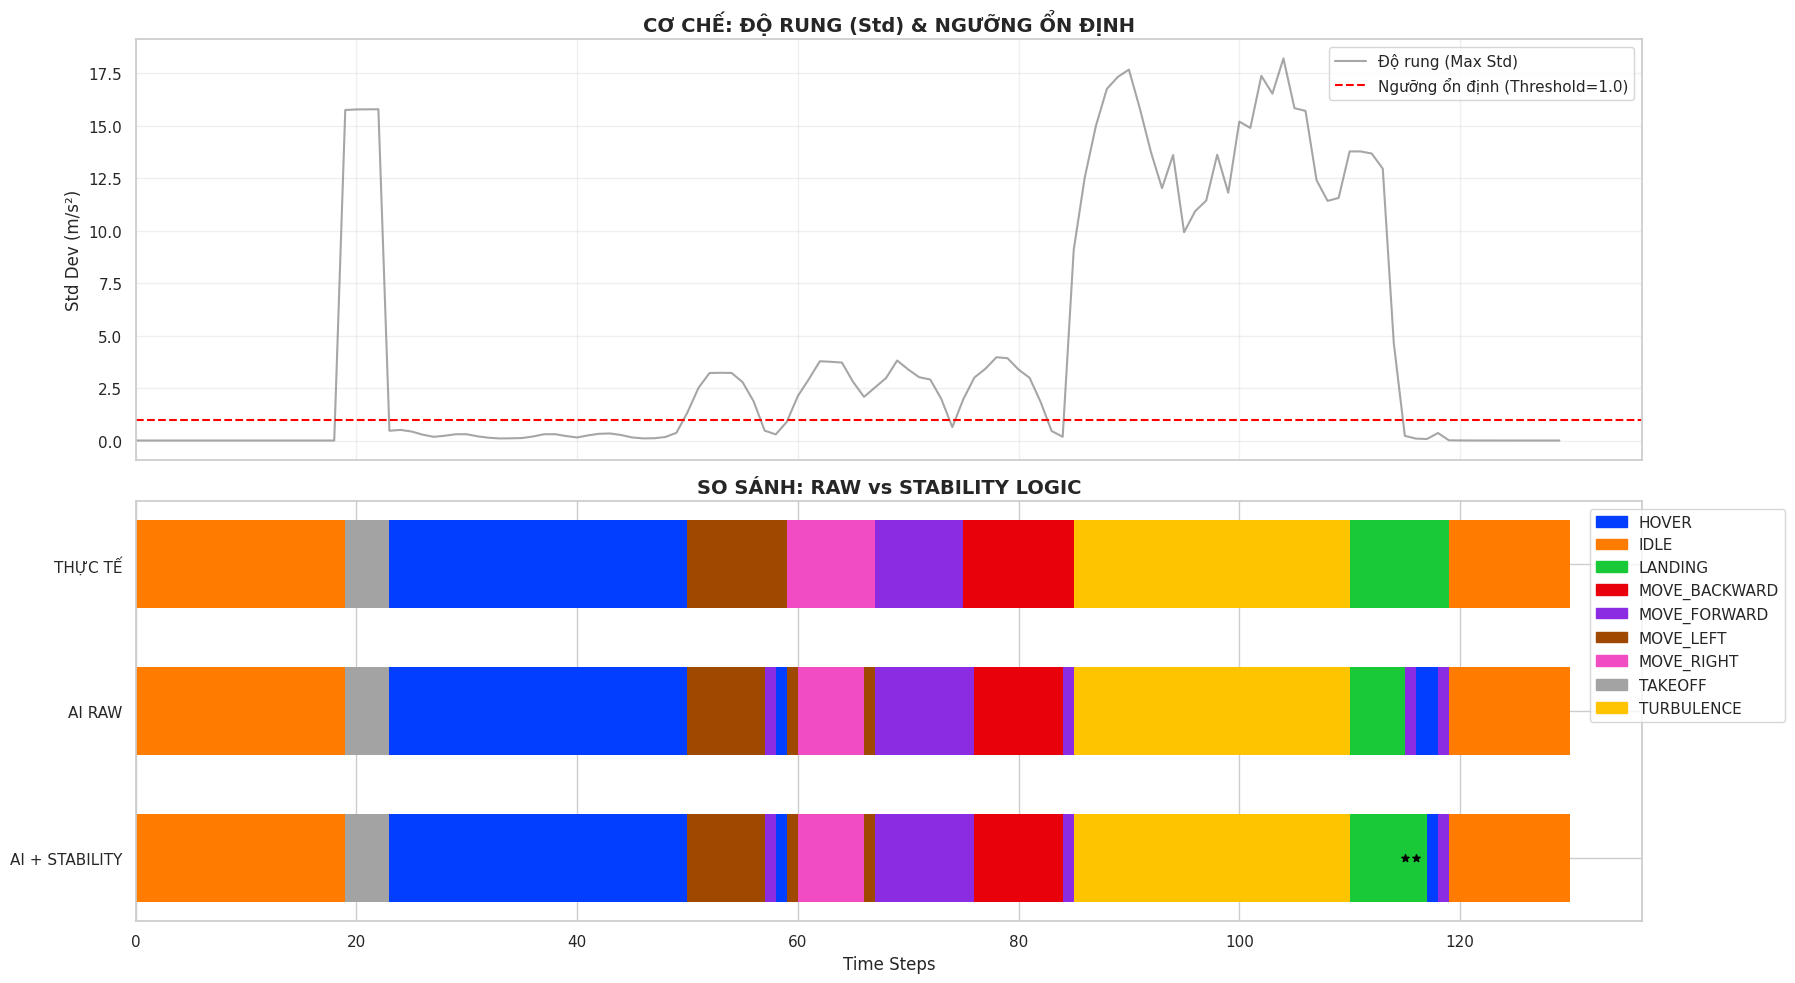

🔹 Raw Accuracy: 92.31%
🚀 Logic Accuracy: 93.85%


In [ ]:
val_path = DATA_DIR / 'val_raw_clean.csv'

if val_path.exists():
    print("⏳ Đang chạy mô phỏng với Logic Stability Buffer...")
    df_val = pd.read_csv(val_path)

    # --- SETUP ---
    WIN_SIZE = 100
    STEP = 20
    feature_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
    model_cols = rf_model.feature_names_in_

    # 🔥 INIT LOGIC: Ngưỡng rung 1.0, cần 3 frame ổn định liên tiếp
    flight_brain = DroneFlightLogic(stability_threshold=1.0, min_stable_frames=3)

    results = {'gt': [], 'raw': [], 'logic': [], 'instability': []}

    unique_segs = df_val['unique_seg_id'].unique() if 'unique_seg_id' in df_val else df_val['segment_id'].unique()

    for seg_id in unique_segs:
        col_id = 'unique_seg_id' if 'unique_seg_id' in df_val else 'segment_id'
        seg_df = df_val[df_val[col_id] == seg_id]
        true_label = seg_df['label'].iloc[0]

        for i in range(0, len(seg_df) - WIN_SIZE + 1, STEP):
            window = seg_df.iloc[i:i+WIN_SIZE]

            feats = extract_features_inference(window[feature_cols].values)
            feats_df = pd.DataFrame([feats]).reindex(columns=model_cols, fill_value=0)

            # AI Predict
            raw_pred = rf_model.predict(feats_df)[0]

            # LOGIC FIX (Truyền thêm features để check độ rung)
            logic_pred = flight_brain.process(raw_pred, feats)

            # Lưu kết quả để vẽ
            results['gt'].append(true_label)
            results['raw'].append(raw_pred)
            results['logic'].append(logic_pred)
            # Lưu độ rung để debug (Max Std)
            instability = max(feats.get('acc_x_std',0), feats.get('acc_y_std',0), feats.get('acc_z_std',0))
            results['instability'].append(instability)

    # --- VISUALIZATION ---
    labels = sorted(list(set(results['gt'] + results['logic'])))
    palette = sns.color_palette("bright", len(labels))
    color_map = {lbl: palette[i] for i, lbl in enumerate(labels)}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

    # CHART 1: ĐỘ RUNG (INSTABILITY) - Để chứng minh tại sao Logic hoạt động
    ax1.set_title("CƠ CHẾ: ĐỘ RUNG (Std) & NGƯỠNG ỔN ĐỊNH", fontsize=14, fontweight='bold')
    ax1.plot(results['instability'], color='gray', label='Độ rung (Max Std)', alpha=0.7)
    ax1.axhline(y=1.0, color='red', linestyle='--', label='Ngưỡng ổn định (Threshold=1.0)')
    ax1.set_ylabel("Std Dev (m/s²)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # CHART 2: TIMELINE
    ax2.set_title("SO SÁNH: RAW vs STABILITY LOGIC", fontsize=14, fontweight='bold')

    def plot_bar(ax, y, data):
        for i, lbl in enumerate(data):
            ax.barh(y, 1, left=i, color=color_map[lbl], edgecolor='none', height=0.6)

    plot_bar(ax2, 2, results['gt'])
    plot_bar(ax2, 1, results['raw'])
    plot_bar(ax2, 0, results['logic'])

    # Đánh dấu chỗ Logic sửa
    changes = [i for i in range(len(results['raw'])) if results['raw'][i] != results['logic'][i]]
    ax2.scatter(changes, [0]*len(changes), marker='*', color='black', s=30, label='Logic Extended', zorder=10)

    ax2.set_yticks([0, 1, 2])
    ax2.set_yticklabels(['AI + STABILITY', 'AI RAW', 'THỰC TẾ'])
    ax2.set_xlabel("Time Steps")

    # Legend
    patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels]
    ax2.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.1, 1))

    plt.tight_layout()
    plt.show()

    # Calculate Accuracy
    acc_raw = accuracy_score(results['gt'], results['raw'])
    acc_logic = accuracy_score(results['gt'], results['logic'])
    print(f"🔹 Raw Accuracy: {acc_raw*100:.2f}%")
    print(f"🚀 Logic Accuracy: {acc_logic*100:.2f}%")

else:
    print("❌ Không tìm thấy file dữ liệu.")